In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import MinMaxScaler
import torch

In [2]:
file_path = '/home/joong/orange/ece-5464/project_3/data/BattingSalariesData.xlsx'
df_batting = pd.read_excel(file_path, sheet_name = "Batting")
print(df_batting.shape)

(45174, 24)


In [3]:
df_batting.head()

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,...,CS,BB,SO,IBB,HBP,SH,SF,GIDP,yearPlayer,Salary
0,aasedo01,1985,1,BAL,AL,54,0,0,0,0,...,0,0,0,0,0,0,0,0,1985aasedo01,NaN
1,abregjo01,1985,1,CHN,NL,6,9,0,0,0,...,0,0,2,0,0,0,0,0,1985abregjo01,NaN
2,ackerji01,1985,1,TOR,AL,61,0,0,0,0,...,0,0,0,0,0,0,0,0,1985ackerji01,170000.0
3,adamsri02,1985,1,SFN,NL,54,121,12,23,3,...,1,5,23,3,1,3,0,2,1985adamsri02,NaN
4,agostju01,1985,1,CHA,AL,54,0,0,0,0,...,0,0,0,0,0,0,0,0,1985agostju01,147500.0


In [4]:
df = df_batting.dropna(subset=["Salary"])

In [5]:
df.shape

(28119, 24)

In [6]:
df["yearPlayer"]= df["yearPlayer"].factorize()[0]

/tmp/ipykernel_12074/1685049675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["yearPlayer"]= df["yearPlayer"].factorize()[0]


In [7]:
df = df.drop(columns = ["playerID"])

In [8]:
df = pd.get_dummies(df, columns=["lgID","teamID"], drop_first=True)

In [9]:
df.head()

,yearID,stint,G,AB,R,H,2B,3B,HR,RBI,...,teamID_PHI,teamID_PIT,teamID_SDN,teamID_SEA,teamID_SFN,teamID_SLN,teamID_TBA,teamID_TEX,teamID_TOR,teamID_WAS
2,1985,1,61,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,1985,1,54,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,1985,1,91,165,27,46,7,3,6,21,...,True,False,False,False,False,False,False,False,False,False
8,1985,1,36,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
10,1985,1,23,2,0,0,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False


In [10]:
scaler = MinMaxScaler()
num_cols = ['G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
df.head()

,yearID,stint,G,AB,R,H,2B,3B,HR,RBI,...,teamID_PHI,teamID_PIT,teamID_SDN,teamID_SEA,teamID_SFN,teamID_SLN,teamID_TBA,teamID_TEX,teamID_TOR,teamID_WAS
2,1985,1,0.00060,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,False,False,False,False,False,False,False,False,True,False
4,1985,1,0.00053,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,False,False,False,False,False,False,False,False,False,False
5,1985,1,0.00090,0.00165,0.00027,0.00046,0.00007,0.00003,0.00006,0.00021,...,True,False,False,False,False,False,False,False,False,False
8,1985,1,0.00035,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,False,False,False,False,False,False,False,False,True,False
10,1985,1,0.00022,0.00002,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,False,False,False,False,False,True,False,False,False,False


In [12]:
x_df = df.drop(columns=["Salary"])

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error


X = x_df
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22222)
reg = LinearRegression().fit(X_train, y_train)

y_pred = reg.predict(X_test)


r2_score = reg.score(X_test, y_test)
print(f"R² Score: {r2_score:.2f}")


mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")


R² Score: 0.26
Mean Squared Error (MSE): 8440073987462.32


In [14]:
for year in df["yearID"].unique():
    df_year = df[df["yearID"] == year]  
    print(f"Year: {year}, Dataset Size: {df_year.shape[0]}")

Year: 1985, Dataset Size: 577
Year: 1986, Dataset Size: 757
Year: 1987, Dataset Size: 669
Year: 1988, Dataset Size: 706
Year: 1989, Dataset Size: 767
Year: 1990, Dataset Size: 892
Year: 1991, Dataset Size: 718
Year: 1992, Dataset Size: 789
Year: 1993, Dataset Size: 963
Year: 1994, Dataset Size: 892
Year: 1995, Dataset Size: 1068
Year: 1996, Dataset Size: 999
Year: 1997, Dataset Size: 995
Year: 1998, Dataset Size: 1063
Year: 1999, Dataset Size: 1043
Year: 2000, Dataset Size: 929
Year: 2001, Dataset Size: 915
Year: 2002, Dataset Size: 889
Year: 2003, Dataset Size: 896
Year: 2004, Dataset Size: 877
Year: 2005, Dataset Size: 880
Year: 2006, Dataset Size: 913
Year: 2007, Dataset Size: 899
Year: 2008, Dataset Size: 887
Year: 2009, Dataset Size: 880
Year: 2010, Dataset Size: 876
Year: 2011, Dataset Size: 881
Year: 2012, Dataset Size: 907
Year: 2013, Dataset Size: 891
Year: 2014, Dataset Size: 882
Year: 2015, Dataset Size: 918
Year: 2016, Dataset Size: 901


In [15]:
from sklearn.model_selection import train_test_split

for year in df["yearID"].unique():
    df_year = df[df["yearID"] == year]  
 
    X = df_year.drop(columns=["Salary"])  
    y = df_year["Salary"]  

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22222)

    print(f"Year {year}: Training set size = {X_train.shape[0]}, Test set size = {X_test.shape[0]}")

Year 1985: Training set size = 403, Test set size = 174
Year 1986: Training set size = 529, Test set size = 228
Year 1987: Training set size = 468, Test set size = 201
Year 1988: Training set size = 494, Test set size = 212
Year 1989: Training set size = 536, Test set size = 231
Year 1990: Training set size = 624, Test set size = 268
Year 1991: Training set size = 502, Test set size = 216
Year 1992: Training set size = 552, Test set size = 237
Year 1993: Training set size = 674, Test set size = 289
Year 1994: Training set size = 624, Test set size = 268
Year 1995: Training set size = 747, Test set size = 321
Year 1996: Training set size = 699, Test set size = 300
Year 1997: Training set size = 696, Test set size = 299
Year 1998: Training set size = 744, Test set size = 319
Year 1999: Training set size = 730, Test set size = 313
Year 2000: Training set size = 650, Test set size = 279
Year 2001: Training set size = 640, Test set size = 275
Year 2002: Training set size = 622, Test set siz

Year 1985: R² = 0.01, MSE = 120423243264.45
Year 1986: R² = 0.07, MSE = 182536562876.34
Year 1987: R² = 0.05, MSE = 150419373244.94
Year 1988: R² = 0.17, MSE = 153615567335.02
Year 1989: R² = 0.03, MSE = 242453001807.32
Year 1990: R² = 0.05, MSE = 242971286495.56
Year 1991: R² = 0.15, MSE = 807347939037.41
Year 1992: R² = -0.07, MSE = 1292288909105.09
Year 1993: R² = 0.10, MSE = 1520423367617.73
Year 1994: R² = 0.11, MSE = 1728730488426.33
Year 1995: R² = 0.24, MSE = 1537515140199.96
Year 1996: R² = 0.32, MSE = 1807672983439.76
Year 1997: R² = 0.29, MSE = 2145415477717.96
Year 1998: R² = 0.25, MSE = 2762234510464.70
Year 1999: R² = 0.23, MSE = 3085536711565.61
Year 2000: R² = 0.16, MSE = 4814656604250.13
Year 2001: R² = 0.27, MSE = 6610543362929.26
Year 2002: R² = 0.24, MSE = 6642558293806.82
Year 2003: R² = 0.24, MSE = 7227338503046.38
Year 2004: R² = 0.16, MSE = 10288070354410.02
Year 2005: R² = 0.13, MSE = 10491215842417.04
Year 2006: R² = 0.26, MSE = 9802445330712.25
Year 2007: R² 

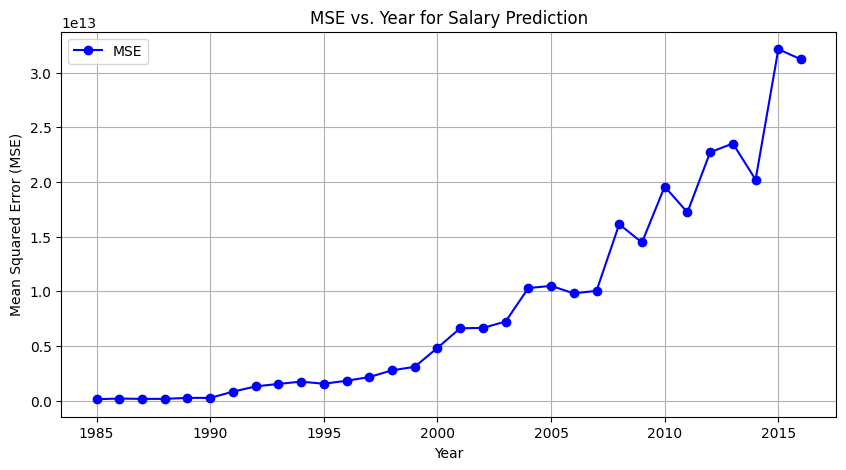

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

years = []
mse_values = []

for year in sorted(df["yearID"].unique()):  
    df_year = df[df["yearID"] == year]  

    X = df_year.drop(columns=["Salary"])
    y = df_year["Salary"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=22222)

    reg = LinearRegression().fit(X_train, y_train)
    y_pred = reg.predict(X_test)  

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)  

    print(f"Year {year}: R² = {r2:.2f}, MSE = {mse:.2f}")

    years.append(year)  
    mse_values.append(mse)  


plt.figure(figsize=(10, 5))
plt.plot(years, mse_values, marker='o', linestyle='-', color='b', label='MSE')

plt.xlabel("Year")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs. Year for Salary Prediction")
plt.legend()
plt.grid(True)
plt.show()